In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are


# --------------------------------------------------
# 1. Physical parameters
# --------------------------------------------------

M = 1.0       # cart mass, kg
m = 0.2       # pendulum mass, kg
l = 0.5       # pendulum length, m
g = 9.81      # gravity, m/s^2
b = 0.1       # cart friction coefficient


# --------------------------------------------------
# 2. Linear state-space model
# --------------------------------------------------

# State vector: [x, x_dot, theta, theta_dot]
# Which can be represented as: X = [x1, x2, x3, x4] = [x, x_dot, theta, theta_dot]
# Thus x1 = x, x2 = x1_dot, x3 = theta, x4 = theta_dot
# We need to come up with the form of the state-space representation: X_dot = A*X + B*u
# Refer to the readme for the derivation of the state-space representation.

A = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, -b / M, -(m * g) / M, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, b / (M * l), ((M + m) * g) / (M * l), 0.0]
])

B = np.array([
    [0.0],
    [1.0 / M],
    [0.0],
    [-1.0 / (M * l)]
])

# Check for system stability
eigenvalues = np.linalg.eigvals(A)
if np.all(np.real(eigenvalues) < 0):
    print("The system is stable.")
else:
    print("The system is unstable.")

# Check of controllability
# The controllability matrix is defined as: C = [B, A*B, A^2*B, A^3*B]
# If the rank of C is equal to the number of states (4 in this case), then the system is controllable.
C = np.hstack([B, A @ B, A @ A @ B, A @ A @ A @ B])
if np.linalg.matrix_rank(C) == 4:
    print("The system is controllable.")

The system is unstable.
The system is controllable.


In [7]:
# --------------------------------------------------
# 3. LQR weighting matrices
# --------------------------------------------------

Q = np.diag([
    10.0,     # cart position
    1.0,      # cart velocity
    100.0,    # pendulum angle
    1.0       # angular velocity
])

R = np.array([[0.1]])

In [9]:
# --------------------------------------------------
# 4. Solve Riccati equation and calculate K
# --------------------------------------------------

# ARE formulation: A^T * P + P * A - P * B * R^-1 * B^T * P + Q = 0

# P is the solution to the continuous-time algebraic Riccati equation (CARE), V(x)=x^T P x
# It is also known as the cost-to-go matrix, which represents the optimal cost for the system.

P = solve_continuous_are(A, B, Q, R)

# K is the optimal state feedback gain matrix, which minimizes the cost function.
# K is calculated as: K = R^-1 * B^T * P

K = np.linalg.solve(R, B.T @ P)

print("LQR gain K:")
print(K)


LQR gain K:
[[-10.         -11.75968929 -73.54476281 -14.83246997]]


In [10]:
# --------------------------------------------------
# 5. Check closed-loop eigenvalues
# --------------------------------------------------

A_closed_loop = A - B @ K

closed_loop_eigenvalues = np.linalg.eigvals(A_closed_loop)

print("\nClosed-loop eigenvalues:")
print(closed_loop_eigenvalues)

# Check if all eigenvalues have negative real parts for stability
if np.all(np.real(closed_loop_eigenvalues) < 0):
    print("The closed-loop system is stable.")
else:
    print("The closed-loop system is unstable.")


Closed-loop eigenvalues:
[-7.67618719+3.33038776j -7.67618719-3.33038776j -1.32643814+1.02117834j
 -1.32643814-1.02117834j]
The closed-loop system is stable.


In [11]:
# --------------------------------------------------
# 6. Define closed-loop dynamics
# --------------------------------------------------

def closed_loop_dynamics(t, state):
    """
    state = [x, x_dot, theta, theta_dot]
    """

    # LQR control law
    u = (-K @ state).item()

    # State derivative
    state_dot = A @ state + B.flatten() * u

    return state_dot

In [12]:
# --------------------------------------------------
# 7. Initial condition
# --------------------------------------------------

initial_state = np.array([
    0.0,                 # cart position, m
    0.0,                 # cart velocity, m/s
    np.deg2rad(10.0),    # pendulum angle, rad
    0.0                  # angular velocity, rad/s
])

In [13]:
# --------------------------------------------------
# 8. Simulation time
# --------------------------------------------------

start_time = 0.0
end_time = 10.0

time_points = np.linspace(
    start_time,
    end_time,
    1000
)

In [14]:
# --------------------------------------------------
# 9. Solve the differential equation
# --------------------------------------------------

solution = solve_ivp(
    fun=closed_loop_dynamics,
    t_span=(start_time, end_time),
    y0=initial_state,
    t_eval=time_points,
    method="RK45"
)

In [15]:
# --------------------------------------------------
# 10. Extract states
# --------------------------------------------------

time = solution.t

cart_position = solution.y[0]
cart_velocity = solution.y[1]
pendulum_angle = solution.y[2]
angular_velocity = solution.y[3]


In [16]:
# --------------------------------------------------
# 11. Calculate control force over time
# --------------------------------------------------

control_force = np.zeros_like(time)

for i in range(len(time)):
    state = solution.y[:, i]
    control_force[i] = (-K @ state).item()



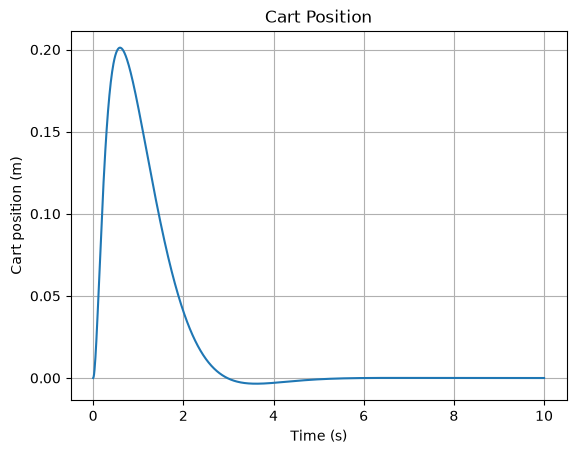

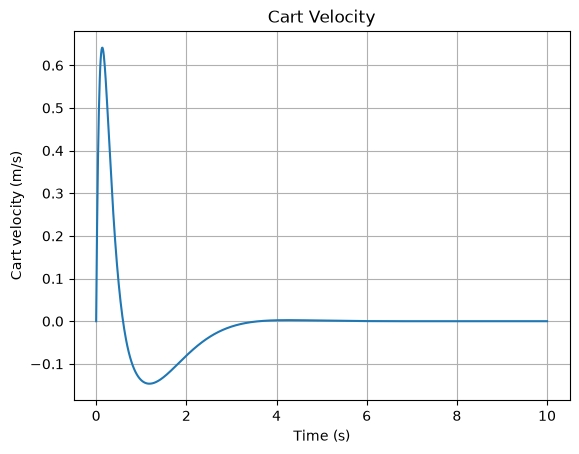

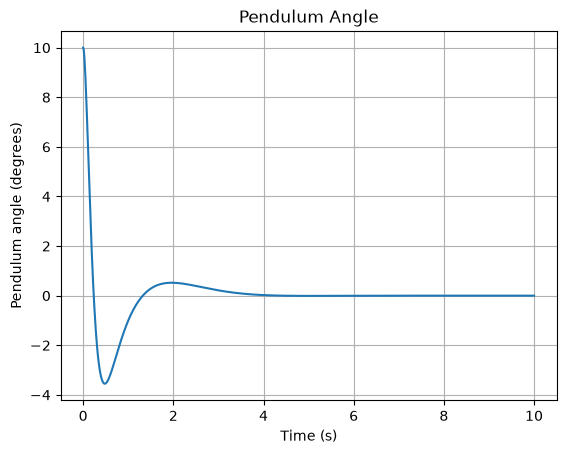

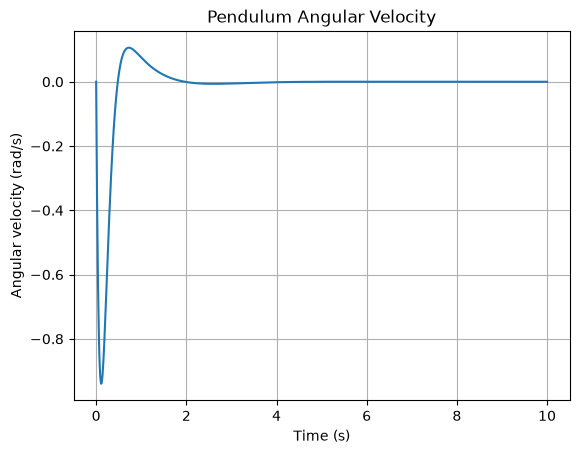

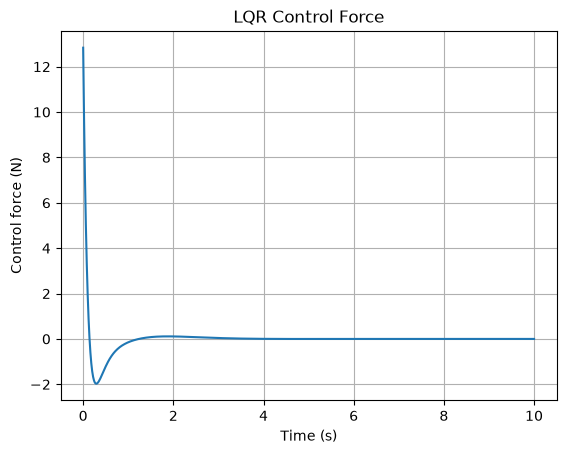

In [17]:
# --------------------------------------------------
# 12. Plot states
# --------------------------------------------------

plt.figure()

plt.plot(time, cart_position)

plt.xlabel("Time (s)")
plt.ylabel("Cart position (m)")
plt.title("Cart Position")

plt.grid(True)
plt.show()


plt.figure()

plt.plot(time, cart_velocity)

plt.xlabel("Time (s)")
plt.ylabel("Cart velocity (m/s)")
plt.title("Cart Velocity")

plt.grid(True)
plt.show()


plt.figure()

plt.plot(time, np.rad2deg(pendulum_angle))

plt.xlabel("Time (s)")
plt.ylabel("Pendulum angle (degrees)")
plt.title("Pendulum Angle")

plt.grid(True)
plt.show()


plt.figure()

plt.plot(time, angular_velocity)

plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Pendulum Angular Velocity")

plt.grid(True)
plt.show()


plt.figure()

plt.plot(time, control_force)

plt.xlabel("Time (s)")
plt.ylabel("Control force (N)")
plt.title("LQR Control Force")

plt.grid(True)
plt.show()